# Auto-regressive Training
This notebook is about building and training simple language models using RNN, LSTM, and GRU.

**Steps:**
1. Setup and get the data (WikiText-2)
2. Build the models (RNN, LSTM, GRU)
3. Train and evaluate the models (using perplexity)
4. Generate text with the trained models

Authors: Suraj & Debajyoti

Reference: [Stanford NLP Book, Chapter 13](https://web.stanford.edu/~jurafsky/slp3/13.pdf)

## § 1 — Setup & Imports

In [1]:
# # Install packages (run once on Colab)
# !pip install -q torch torchtext datasets sacrebleu tqdm pandas matplotlib

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
import time, math, random, json
from collections import Counter
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
  GPU: NVIDIA A100 80GB PCIe


## 2. Data: WikiText-2

Compared to the preprocessed version of Penn Treebank (PTB), WikiText-2 (44.8k rows) is over 2 times larger. The WikiText dataset also features a far larger vocabulary and retains the original case, punctuation and numbers - all of which are removed in PTB. As it is composed of full articles, the dataset is well suited for models that can take advantage of long term dependencies.

In [3]:
from datasets import load_dataset

print("Loading WikiText-2...")
raw_dataset = load_dataset("wikitext", "wikitext-2-raw-v1")

# Dataset statistics
for split in raw_dataset:
    texts = [t for t in raw_dataset[split]['text'] if t.strip()]
    tokens = sum(len(t.split()) for t in texts)
    print(f"  {split:12s}: {len(texts):6,} articles | {tokens:8,} tokens")

print()
# Sample line
samples = [t for t in raw_dataset['train']['text'] if len(t.strip()) > 100][:2]
for s in samples:
    print(f"  Sample: {s[:130]}...")
    print()

Loading WikiText-2...
  test        :  2,891 articles |  241,211 tokens
  train       : 23,767 articles | 2,051,910 tokens
  validation  :  2,461 articles |  213,886 tokens

  Sample:  Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred ...

  Sample:  The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained...



In [4]:
# ── Vocabulary Building ──────────────────────────────────────────────────────

def build_vocab(texts, min_freq=2, max_vocab=20000):
    """Word-level vocabulary with special tokens."""
    counter = Counter()
    for text in texts:
        counter.update(text.lower().split())
    vocab = {'<pad>': 0, '<sos>': 1, '<eos>': 2, '<unk>': 3}
    for word, freq in counter.most_common(max_vocab):
        if freq >= min_freq and word not in vocab:
            vocab[word] = len(vocab)
    return vocab

train_texts = [t for t in raw_dataset['train']['text'] if t.strip()]
vocab = build_vocab(train_texts)
idx2word = {v: k for k, v in vocab.items()}
VOCAB_SIZE = len(vocab)
print(f"Vocabulary size: {VOCAB_SIZE:,}")
print(f"Top-10 words: {list(vocab.keys())[4:14]}")

Vocabulary size: 20,004
Top-10 words: ['the', ',', '.', 'of', 'and', 'in', 'to', 'a', '=', '"']


In [5]:
# ── Dataset & DataLoader ─────────────────────────────────────────────────────

class WikiTextDataset(Dataset):
    """
    Sliding-window sequences for language modeling.
    Each sample: (x, y) where y = x shifted right by 1.
    """
    def __init__(self, texts, vocab, seq_len=64):
        self.seq_len = seq_len
        # Tokenise & concatenate all articles with <eos> separator
        all_tokens = []
        for text in texts:
            if text.strip():
                tokens = [vocab.get(w, vocab['<unk>']) for w in text.lower().split()]
                if tokens:
                    all_tokens.extend(tokens)
                    all_tokens.append(vocab['<eos>'])
        self.tokens = torch.tensor(all_tokens, dtype=torch.long)
        self.n_seqs = (len(self.tokens) - 1) // seq_len

    def __len__(self): return self.n_seqs

    def __getitem__(self, idx):
        s = idx * self.seq_len
        return self.tokens[s:s+self.seq_len], self.tokens[s+1:s+self.seq_len+1]

SEQ_LEN, BATCH_SIZE = 64, 64

print("Building datasets...")
train_ds = WikiTextDataset([t for t in raw_dataset['train']['text'] if t.strip()], vocab, SEQ_LEN)
val_ds   = WikiTextDataset([t for t in raw_dataset['validation']['text'] if t.strip()], vocab, SEQ_LEN)
test_ds  = WikiTextDataset([t for t in raw_dataset['test']['text'] if t.strip()], vocab, SEQ_LEN)

print(f"  Train: {len(train_ds):,} sequences")
print(f"  Val:   {len(val_ds):,} sequences")
print(f"  Test:  {len(test_ds):,} sequences")

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  pin_memory=True, num_workers=2)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, pin_memory=True)
test_loader  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, pin_memory=True)
print(f"\nLoaders ready. Batches — Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

Building datasets...
  Train: 32,432 sequences
  Val:   3,380 sequences
  Test:  3,814 sequences

Loaders ready. Batches — Train: 507, Val: 53, Test: 60


## 3. Model Implementations

All three models use the same interface: `forward(x, hidden)` returns `(logits, hidden)`.

In [6]:
class RNNLanguageModel(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers=2, dropout=0.3):
        super().__init__()
        self.hidden_size, self.num_layers = hidden_size, num_layers
        self.model_type = 'RNN'
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.rnn = nn.RNN(embed_size, hidden_size, num_layers, batch_first=True,
                          dropout=dropout if num_layers>1 else 0, nonlinearity='tanh')
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, vocab_size, bias=False)

    def forward(self, x, hidden=None):
        out, hidden = self.rnn(self.drop(self.embedding(x)), hidden)
        return self.fc(self.drop(out)), hidden

    def init_hidden(self, batch_size):
        return torch.zeros(self.num_layers, batch_size, self.hidden_size, device=device)

print("RNNLanguageModel defined")

RNNLanguageModel defined


In [7]:
class LSTMLanguageModel(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers=2, dropout=0.3):
        super().__init__()
        self.hidden_size, self.num_layers = hidden_size, num_layers
        self.model_type = 'LSTM'
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True,
                            dropout=dropout if num_layers>1 else 0)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, vocab_size, bias=False)

    def forward(self, x, hidden=None):
        out, hidden = self.lstm(self.drop(self.embedding(x)), hidden)
        return self.fc(self.drop(out)), hidden

    def init_hidden(self, batch_size):
        z = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=device)
        return (z, z.clone())

print("LSTMLanguageModel defined")

LSTMLanguageModel defined


In [8]:
class GRULanguageModel(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers=2, dropout=0.3):
        super().__init__()
        self.hidden_size, self.num_layers = hidden_size, num_layers
        self.model_type = 'GRU'
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.gru = nn.GRU(embed_size, hidden_size, num_layers, batch_first=True,
                          dropout=dropout if num_layers>1 else 0)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, vocab_size, bias=False)

    def forward(self, x, hidden=None):
        out, hidden = self.gru(self.drop(self.embedding(x)), hidden)
        return self.fc(self.drop(out)), hidden

    def init_hidden(self, batch_size):
        return torch.zeros(self.num_layers, batch_size, self.hidden_size, device=device)

print("GRULanguageModel defined")

GRULanguageModel defined


In [9]:
EMBED_SIZE  = 128
HIDDEN_SIZE = 128
NUM_LAYERS  = 1
DROPOUT     = 0.3

def count_params(m): 
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

rnn_model  = RNNLanguageModel( VOCAB_SIZE, EMBED_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)
lstm_model = LSTMLanguageModel(VOCAB_SIZE, EMBED_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)
gru_model  = GRULanguageModel( VOCAB_SIZE, EMBED_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)

print(f"{'='*58}")
print(f"  {'Model':<10} {'Params':>10}  {'Recurrent core':<25} Layers")
print(f"{'='*58}")
for m, n in [(rnn_model,'RNN'), (lstm_model,'LSTM'), (gru_model,'GRU')]:
    core = {'RNN':'1 gate (tanh)','LSTM':'3 gates + cell state','GRU':'2 gates (no cell)'}[n]
    print(f"  {n:<10} {count_params(m):>10,}  {core:<25} {NUM_LAYERS}")
print(f"{'='*58}")
print(f"\n  embed_size={EMBED_SIZE}, hidden_size={HIDDEN_SIZE}, dropout={DROPOUT}")

  Model          Params  Recurrent core            Layers
  RNN         5,154,048  1 gate (tanh)             1
  LSTM        5,253,120  3 gates + cell state      1
  GRU         5,220,096  2 gates (no cell)         1

  embed_size=128, hidden_size=128, dropout=0.3


## 5. Training

- Loss: CrossEntropyLoss (ignores `<pad>` tokens)
- Teacher forcing: uses the true token as the next input
- Gradient clipping: keeps gradients stable
- Truncated BPTT: detaches hidden state between batches
- Optimizer: Adam with learning rate reduction on plateau

In [ ]:
def compute_perplexity(loss):
    return math.exp(min(loss, 20))   # cap to prevent overflow

def detach_hidden(h):
    """Detach hidden state from computation graph (truncated BPTT)."""
    return tuple(x.detach() for x in h) if isinstance(h, tuple) else h.detach()

# ── Hybrid training loop (mix teacher forcing and AR) ──────────────────────────────
def train_epoch_hybrid(model, loader, optimizer, criterion, alpha=0.5, clip=1.0):
    """
    Hybrid training: at each step, input is a mix of gold token and previous model prediction.
    alpha: weight for gold input (1.0 = teacher forcing, 0.0 = fully autoregressive)
    """
    model.train()
    total_loss, hidden = 0.0, None

    for x, y in tqdm(loader, desc="  train (Hybrid)", leave=False):
        x, y = x.to(device), y.to(device)
        bs, seq_len = x.size()

        # Reset / resize hidden state between batches
        if hidden is None or (isinstance(hidden, tuple) and hidden[0].size(1) != bs) or \
           (not isinstance(hidden, tuple) and hidden.size(1) != bs):
            hidden = model.init_hidden(bs)
        hidden = detach_hidden(hidden)

        optimizer.zero_grad()
        inp = x[:, 0:1]  # (B, 1) — seed with gold token
        batch_loss = torch.tensor(0.0, device=device)

        for t in range(seq_len):
            gold_emb = model.embedding(x[:, t:t+1])
            if t == 0:
                prev_emb = gold_emb
            else:
                prev_emb = model.embedding(prev_pred)
            mixed_emb = alpha * gold_emb + (1 - alpha) * prev_emb
            
            if hasattr(model, "rnn"):
                out, hidden = model.rnn(model.drop(mixed_emb), hidden)
            elif hasattr(model, "lstm"):
                out, hidden = model.lstm(model.drop(mixed_emb), hidden)
            elif hasattr(model, "gru"):
                out, hidden = model.gru(model.drop(mixed_emb), hidden)
            else:
                raise ValueError("Unknown model type")
            logits_t = model.fc(model.drop(out)).squeeze(1)
                
            batch_loss = batch_loss + criterion(logits_t, y[:, t])

            with torch.no_grad():
                prev_pred = logits_t.argmax(dim=-1, keepdim=True)

        loss = batch_loss / seq_len
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, hidden = 0, None
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            bs = x.size(0)
            if hidden is None or (isinstance(hidden, tuple) and hidden[0].size(1) != bs) or \
               (not isinstance(hidden, tuple) and hidden.size(1) != bs):
                hidden = model.init_hidden(bs)
            hidden = detach_hidden(hidden)
            logits, hidden = model(x, hidden)
            total_loss += criterion(logits.view(-1, logits.size(-1)), y.view(-1)).item()
    return total_loss / len(loader)

print("Autoregressive training utilities defined")

Autoregressive training utilities defined


In [11]:
# ── Hybrid train_model function ────────────────────────────────────────────────────
def train_model(model, name, n_epochs=3, lr=3e-3, alpha=0.5):
    criterion = nn.CrossEntropyLoss(ignore_index=0)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=1, factor=0.5)
    history = {'train_ppl': [], 'val_ppl': []}
    best_val_loss, best_state = float('inf'), None

    print(f"\n{'='*62}")
    print(f"  Training {name} [Hybrid] | {count_params(model):,} params | {n_epochs} epochs")
    print(f"{'='*62}")

    for epoch in range(1, n_epochs+1):
        t0 = time.time()
        train_loss = train_epoch_hybrid(model, train_loader, optimizer, criterion, alpha=alpha)
        val_loss   = evaluate(model, val_loader, criterion)
        scheduler.step(val_loss)
        train_ppl, val_ppl = compute_perplexity(train_loss), compute_perplexity(val_loss)
        history['train_ppl'].append(train_ppl)
        history['val_ppl'].append(val_ppl)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f"  Epoch {epoch}/{n_epochs} | Train PPL: {train_ppl:7.1f} | Val PPL: {val_ppl:7.1f} | {time.time()-t0:.0f}s")

    model.load_state_dict(best_state)
    print(f"  Best val PPL: {compute_perplexity(best_val_loss):.1f}")
    return history


# ── Train all three models ────────────────────────────────────────────────────
N_EPOCHS = 3

rnn_hist  = train_model(rnn_model,  'RNN', N_EPOCHS)
lstm_hist = train_model(lstm_model, 'LSTM',        N_EPOCHS)
gru_hist  = train_model(gru_model,  'GRU',         N_EPOCHS)


  Training Vanilla RNN [Hybrid] | 5,154,048 params | 3 epochs


  Epoch 1/3 | Train PPL:   819.9 | Val PPL:   429.2 | 45s


  Epoch 2/3 | Train PPL:   495.3 | Val PPL:   318.5 | 45s


  Epoch 3/3 | Train PPL:   393.2 | Val PPL:   277.5 | 44s
  Best val PPL: 277.5

  Training LSTM [Hybrid] | 5,253,120 params | 3 epochs


  Epoch 1/3 | Train PPL:   757.1 | Val PPL:   391.3 | 58s


  Epoch 2/3 | Train PPL:   429.6 | Val PPL:   300.1 | 72s


  Epoch 3/3 | Train PPL:   348.0 | Val PPL:   261.8 | 77s
  Best val PPL: 261.8

  Training GRU [Hybrid] | 5,220,096 params | 3 epochs


  Epoch 1/3 | Train PPL:   802.2 | Val PPL:   418.0 | 66s


  Epoch 2/3 | Train PPL:   491.7 | Val PPL:   316.8 | 75s


  Epoch 3/3 | Train PPL:   393.3 | Val PPL:   273.0 | 50s
  Best val PPL: 273.0


## 6. Evaluation

Perplexity measures how well the model predicts the next word. Lower is better.

In [12]:
# ── Test Perplexity ──────────────────────────────────────────────────────────

criterion = nn.CrossEntropyLoss(ignore_index=0)
results = {}

print("\n" + "="*58)
print(f"  {'Model':<12} {'Test PPL':>10} {'Val PPL':>10} {'#Params':>11}")
print("="*58)
for model, name in [(rnn_model,'RNN'), (gru_model,'GRU'), (lstm_model,'LSTM')]:
    test_loss = evaluate(model, test_loader, criterion)
    val_loss  = evaluate(model, val_loader,  criterion)
    test_ppl, val_ppl = compute_perplexity(test_loss), compute_perplexity(val_loss)
    results[name] = {'test_ppl': test_ppl, 'val_ppl': val_ppl, 'params': count_params(model)}
    print(f"  {name:<12} {test_ppl:>10.1f} {val_ppl:>10.1f} {count_params(model):>11,}")
print("="*58)
print("  Lower perplexity = better language model")


  Model          Test PPL    Val PPL     #Params
  RNN               258.0      277.5   5,154,048
  GRU               250.1      273.0   5,220,096
  LSTM              241.8      261.8   5,253,120
  Lower perplexity = better language model


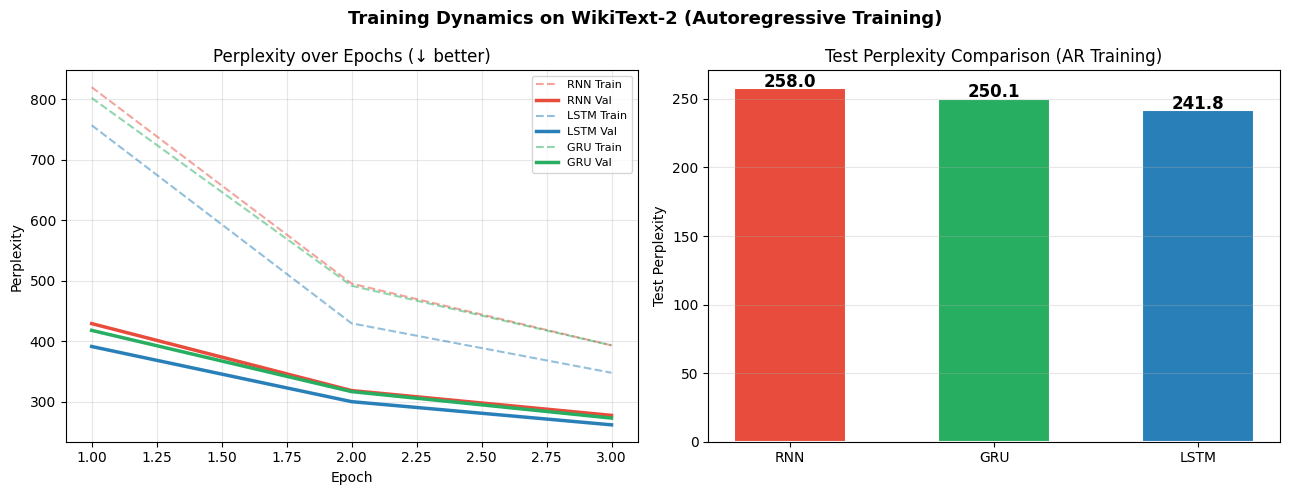

Saved: learning_curves_ar.png


In [13]:
# ── Learning Curves ──────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Training Dynamics on WikiText-2 (Autoregressive Training)', fontsize=13, fontweight='bold')

COLORS = {'RNN': '#e74c3c', 'LSTM': '#2980b9', 'GRU': '#27ae60'}
EPOCHS = list(range(1, N_EPOCHS+1))

for name, hist in [('RNN', rnn_hist), ('LSTM', lstm_hist), ('GRU', gru_hist)]:
    c = COLORS[name]
    axes[0].plot(EPOCHS, hist['train_ppl'], '--', color=c, alpha=0.5, label=f'{name} Train')
    axes[0].plot(EPOCHS, hist['val_ppl'],   '-',  color=c, lw=2.5, label=f'{name} Val')

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Perplexity')
axes[0].set_title('Perplexity over Epochs (↓ better)')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# Bar chart of test PPL
names = ['RNN', 'GRU', 'LSTM']
ppls  = [results['RNN']['test_ppl'], results['GRU']['test_ppl'], results['LSTM']['test_ppl']]
bars  = axes[1].bar(names, ppls, color=[COLORS['RNN'], COLORS['GRU'], COLORS['LSTM']],
                    edgecolor='white', linewidth=1.5, width=0.55)
for bar, val in zip(bars, ppls):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f'{val:.1f}', ha='center', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Test Perplexity'); axes[1].set_title('Test Perplexity Comparison (AR Training)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves_ar.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: learning_curves_ar.png")

## 7. Autoregressive Text Generation

To generate text:
- Encode a seed text
- Feed the token to the model, sample the next token, and repeat until end of sentence or max length

Temperature controls randomness:
- Less than 1.0: more conservative, picks high-probability words
- 1.0: normal model output
- Greater than 1.0: more creative, more random choices

In [14]:
def generate(model, seed, vocab, idx2word, max_len=60, temperature=0.8, top_k=40):
    """Autoregressive generation —"""
    model.eval()
    tokens = [vocab.get(w, vocab['<unk>']) for w in seed.lower().split()] or [vocab['<sos>']]
    generated = tokens.copy()

    with torch.no_grad():
        x = torch.tensor([tokens], dtype=torch.long, device=device)
        hidden = model.init_hidden(1)
        logits, hidden = model(x, hidden)
        inp = torch.tensor([[generated[-1]]], dtype=torch.long, device=device)

        for _ in range(max_len):
            logits, hidden = model(inp, hidden)
            logits = logits[:, -1, :] / temperature
            if top_k > 0:                                # top-k nucleus filtering
                top_vals, _ = torch.topk(logits, top_k)
                logits[logits < top_vals[:, -1:]] = float('-inf')
            probs = torch.softmax(logits, dim=-1)
            nxt = torch.multinomial(probs, 1).item()
            generated.append(nxt)
            if nxt == vocab['<eos>']: break
            inp = torch.tensor([[nxt]], dtype=torch.long, device=device)

    return ' '.join(idx2word.get(t, '<unk>') for t in generated)

# ── Qualitative Comparison ────────────────────────────────────────────────────
seeds = [
    "the history of",
    "in the nineteenth century",
    "scientists have discovered",
    "the university was founded in",
]

print("\n" + "="*72)
print("  QUALITATIVE TEXT GENERATION COMPARISON (temperature=0.8, top_k=40)")
print("="*72)
for seed in seeds:
    print(f"\nSeed: \"{seed}\"")
    print("-"*72)
    for m, n in [(rnn_model,'RNN '), (gru_model,'GRU '), (lstm_model,'LSTM')]:
        print(f"  [{n}] {generate(m, seed, vocab, idx2word)}")


  QUALITATIVE TEXT GENERATION COMPARISON (temperature=0.8, top_k=40)

Seed: "the history of"
------------------------------------------------------------------------
  [RNN ] the history of the 20th century ( 2 @.@ 0 ) ( 3 @.@ 91 m , <unk> , <unk> , and <unk> and <unk> <unk> , the , <unk> he went to the <unk> and the main army . the <unk> of the company ( <unk> ) and a member of the latter , and the latter is the first year .
  [GRU ] the history of the <unk> <unk> and is seen as the best important . <eos>
  [LSTM] the history of his mother were released from the first time , " . <eos>

Seed: "in the nineteenth century"
------------------------------------------------------------------------
  [RNN ] in the nineteenth century . <eos>
  [GRU ] in the nineteenth century , but was used from the third fleet of the mouth of the city . <eos>
  [LSTM] in the nineteenth century , <eos>

Seed: "scientists have discovered"
------------------------------------------------------------------------

In [15]:
# ── Temperature Ablation Study ────────────────────────────────────────────────

seed = "the history of science"
print(f"\nTemperature Ablation | Model: LSTM | Seed: \"{seed}\"")
print("="*72)
for T in [0.4, 0.7, 1.0, 1.4]:
    label = {0.4:'conservative', 0.7:'balanced', 1.0:'raw model', 1.4:'creative/noisy'}[T]
    gen = generate(lstm_model, seed, vocab, idx2word, temperature=T)
    print(f"  T={T} ({label}):")
    print(f"    {gen}")
    print


Temperature Ablation | Model: LSTM | Seed: "the history of science"
  T=0.4 (conservative):
    the history of science , the first time , the <unk> <unk> , <unk> , <unk> , <unk> <unk> , <unk> , <unk> , the <unk> of the <unk> , the <unk> of the song was the first <unk> . <eos>
  T=0.7 (balanced):
    the history of science horse were constructed to the first <unk> in an alternative season . the same year and the end of the world war , the game ( $ 5 m ) ; they is located at the <unk> , the two years . <eos>
  T=1.0 (raw model):
    the history of science ( 6 / , which was made at the world war at $ 2 percent of <eos>
  T=1.4 (creative/noisy):
    the history of science @-@ priest , at three days was released for its first @-@ hungarian years , the <unk> at a tropical song and was no other hundred feet ( 22 million ) south to <unk> ( 30 m ) . its name by new york city . it has taken down to a major single <unk> . <eos>
